## How to use the dual_autodiff package

### Importing the dual_autodiff package

In [1]:
from dual_autodiff.dual import Dual
import math

### Using the dual_autodiff package

In [2]:
# Assign variable x to a dual number with real part 1 and dual part 5
x = Dual(1,5)

In [3]:
# to extract the real part of a Dual number, use .real
print(x.real)

# to extract only the dual part of a Dual number, use .dual
print(x.dual)

1
5


In [4]:
# Package will handle strings of number inputs but will warn user about proper usage
Dual('1','1')

Dual(1.0, 1.0)

In [5]:
# creating two variables equal to Dual numbers and summing them together
x = Dual(1,5)
y = Dual(2,3)
x+y

Dual(3, 8)

In [6]:
# multiplying 2 Dual numbers and printing the result
print("Dual(2, 1) * Dual(3, 2) = ", Dual(2, 1) * Dual(3, 2))

# dividing one Dual number by another and printing the result
result_div = Dual(2, 1) / Dual(4, 2)
print(result_div)

Dual(2, 1) * Dual(3, 2) =  Dual(6, 7)
Dual(0.5, 0.0)


In [7]:
# our package can raise dual numbers to both real and dual powers
# raising Dual number to real power
result_pow1 = Dual(2, 1) ** 2
print(result_pow1)

# raising Dual number to Dual power
result_pow2 = Dual(2, 1) ** Dual(3, 2)
print(result_pow2)

Dual(4, 4)
Dual(8, 23.090354888959126)


In [8]:
# Computing the sine of a Dual number
Dual(2, 1).sin()

Dual(0.9092974268256817, -0.4161468365471424)

In [9]:
import numpy as np

# Computing sine, cosine, and tangent of a Dual number
sin_res = Dual(3, 2).sin()
cos_res = Dual(3, 2).cos()
tan_res = Dual(3, 2).tan()
print(f"Sine of Dual(3,2) is: {sin_res}")
print(f"Cosine of Dual(3,2) is: {cos_res}")
print(f"Tangent of Dual(3,2) is: {tan_res}")

# and checking that the relationship between trigonometric functions holds as expected
# using np.allclose instead of == due to float-point instability
print("Real part behaves according to trigonometric definitions:", np.allclose((sin_res / cos_res).real, tan_res.real))
print("Dual part behaves according to trigonometric definitions:", np.allclose((sin_res / cos_res).dual, tan_res.dual))

Sine of Dual(3,2) is: Dual(0.1411200080598672, -1.9799849932008908)
Cosine of Dual(3,2) is: Dual(-0.9899924966004454, -0.2822400161197344)
Tangent of Dual(3,2) is: Dual(-0.1425465430742778, 2.040639033884854)
Real part behaves according to trigonometric definitions: True
Dual part behaves according to trigonometric definitions: True


In [10]:
#computing natural logarithm of a Dual number
y = Dual(4,1).log()
print(f"Logarithm of Dual(4,1) is {y}")

# computing exponential of a Dual number
z = y.exp()
print(f"Exponential of {y} is {z} as expected")

Logarithm of Dual(4,1) is Dual(1.3862943611198906, 0.25)
Exponential of Dual(1.3862943611198906, 0.25) is Dual(4.0, 1.0) as expected


### Example of automatic differentiation performed by the package

In [11]:
# define a function
def f(x):
    return (x.sin()).log()+x*x*(x.cos())

x=Dual(1.5,1)

# print the result where the dual part will be the derivative of the function at x=1.5
print(f(x))

Dual(0.15665054756073515, -1.9612372705533612)


In [12]:
# this is the derivative of the function f(x) at x=1.5 computed analytically
# let's compare it to the result received from our package
def deriv_f(x):
    return (math.cos(x) / math.sin(x)) + 2*x*math.cos(x) - math.sin(x)*x**2

print("Analytical derivative at x=1.5: ", deriv_f(1.5))
print("Derivative computed using Dual numbers x=1.5: ", f(x).dual)
print(f"Are they equal? {deriv_f(1.5) == f(x).dual}")

Analytical derivative at x=1.5:  -1.9612372705533612
Derivative computed using Dual numbers x=1.5:  -1.9612372705533612
Are they equal? True


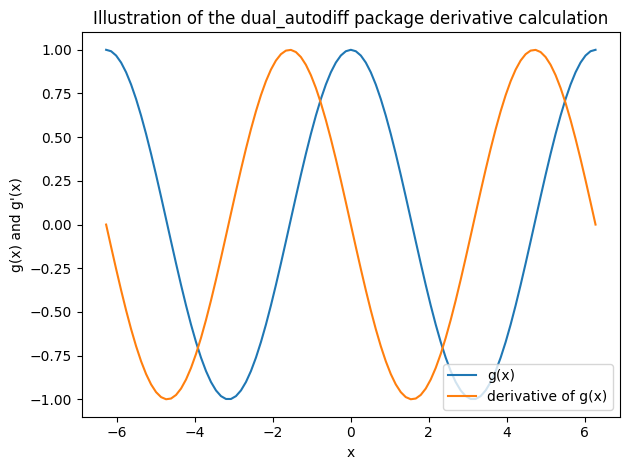

In [13]:
# we can compute the derivative of the function at many points using the dual_autodiff package
import matplotlib.pyplot as plt

x = np.linspace(-2*math.pi,2*math.pi,99)
#xD = np.array([f(Dual(x_i,0)).dual for x_i in x])

def g(x):
    return x.cos()

# compute the derivative of g(x) at many points using the dual_autodiff package
xD_g = np.array([g(Dual(x_i,1)).dual for x_i in x])
xR_g = np.array([g(Dual(x_i,1)).real for x_i in x])

# plot the results
plt.plot(x,xR_g, label='g(x)')
plt.plot(x,xD_g, label='derivative of g(x)')
plt.legend(loc='lower right')
plt.xlabel('x')
plt.ylabel("g(x) and g'(x)")
plt.title("Illustration of the dual_autodiff package derivative calculation")
plt.tight_layout()
plt.show()

# As we can see, the dual_autodiff package is able to compute the derivative of the function 
# at many points accurately, building the derivative function

## Performance comparison of pure python package and cythonized package

In [14]:
#import the cythonized package
from dual_autodiff_x import dual as dfx

#import time for the comparison
import timeit

In [15]:
# cell that performs all the operations using the python version of the package
# stores times in the array
np.random.seed(24) #set a random seed
python_times = []

# single instance creation
time_taken = timeit.timeit("x = Dual(1,5)", globals=globals(), number=1000)
python_times.append(time_taken)

# addition
time_taken = timeit.timeit("Dual(2, 1) + Dual(3, 2)", globals=globals(), number=1000)
python_times.append(time_taken)

# multiplication
time_taken = timeit.timeit("Dual(2, 1) * Dual(3, 2)", globals=globals(), number=1000)
python_times.append(time_taken)

# division
time_taken = timeit.timeit("Dual(2, 1) / Dual(4, 2)", globals=globals(), number=1000)
python_times.append(time_taken)

# sine
time_taken = timeit.timeit("Dual(2, 1).sin()", globals=globals(), number=1000)
python_times.append(time_taken)

# cosine
time_taken = timeit.timeit("Dual(2, 1).cos()", globals=globals(), number=1000)
python_times.append(time_taken)

# tangent
time_taken = timeit.timeit("Dual(2, 1).tan()", globals=globals(), number=1000)
python_times.append(time_taken)

# logarithm
time_taken = timeit.timeit("Dual(2, 1).log()", globals=globals(), number=1000)
python_times.append(time_taken)

# exponentiation
time_taken = timeit.timeit("Dual(2, 1).exp()", globals=globals(), number=1000)
python_times.append(time_taken)

# power
time_taken = timeit.timeit("Dual(2, 1) ** (Dual(2,1))", globals=globals(), number=1000)
python_times.append(time_taken)


In [16]:
# cell that performs all the operations using the cython version of the package
# in the same order and stores times in the array
cython_times = []

# single instance creation
time_taken = timeit.timeit("x = dfx.Dual(1,5)", globals=globals(), number=1000)
cython_times.append(time_taken)

# addition
time_taken = timeit.timeit("dfx.Dual(2, 1) + dfx.Dual(3, 2)", globals=globals(), number=1000)
cython_times.append(time_taken)

# multiplication
time_taken = timeit.timeit("dfx.Dual(2, 1) * dfx.Dual(3, 2)", globals=globals(), number=1000)
cython_times.append(time_taken)

# division
time_taken = timeit.timeit("dfx.Dual(2, 1) / dfx.Dual(4, 2)", globals=globals(), number=1000)
cython_times.append(time_taken)

# sine
time_taken = timeit.timeit("dfx.Dual(2, 1).sin()", globals=globals(), number=1000)
cython_times.append(time_taken)

# cosine
time_taken = timeit.timeit("dfx.Dual(2, 1).cos()", globals=globals(), number=1000)
cython_times.append(time_taken)

# tangent
time_taken = timeit.timeit("dfx.Dual(2, 1).tan()", globals=globals(), number=1000)
cython_times.append(time_taken)

# logarithm
time_taken = timeit.timeit("dfx.Dual(2, 1).log()", globals=globals(), number=1000)
cython_times.append(time_taken)

# exponentiation
time_taken = timeit.timeit("dfx.Dual(2, 1).exp()", globals=globals(), number=1000)
cython_times.append(time_taken)

# power
time_taken = timeit.timeit("dfx.Dual(2, 1) ** (dfx.Dual(2,1))", globals=globals(), number=1000)
cython_times.append(time_taken)

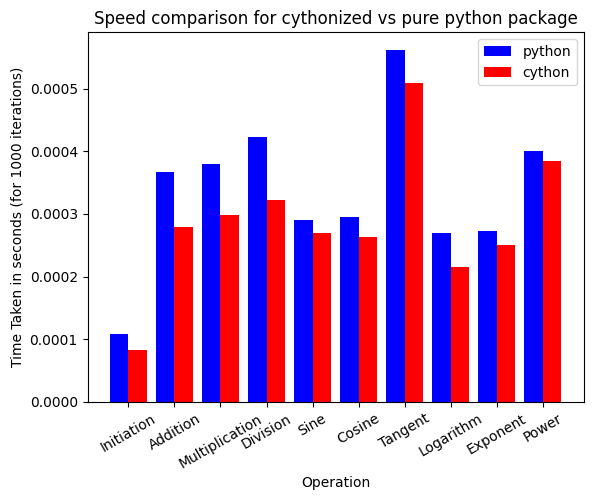

In [17]:
# making a bar plot to see the difference in time execution between cython and python versions
import numpy as np
import matplotlib.pyplot as plt
methods = ['Python', 'Cython']

# Create the bar positions
indices = np.arange(len(python_times))

# Custom text labels for x-axis
labels = ['Initiation', 'Addition', 'Multiplication', 'Division', 'Sine', 'Cosine',
        'Tangent', 'Logarithm', 'Exponent', 'Power']  # Text labels for x-axis

# Plot the bars
plt.bar(indices - 0.2, python_times, width=0.4, label='python', color='b')
plt.bar(indices + 0.2, cython_times, width=0.4, label='cython', color='r')

# Customize plot
plt.xlabel("Operation")
plt.ylabel("Time Taken in seconds (for 1000 iterations)")
plt.title("Speed comparison for cythonized vs pure python package")
plt.xticks(indices, labels, rotation=30)
plt.legend()

# Show plot
plt.show()

[0.76538996 0.76082926 0.78540155 0.76139928 0.92582328 0.89404897
 0.90684444 0.79937848 0.92217977 0.96169813]
0.8482993118373674


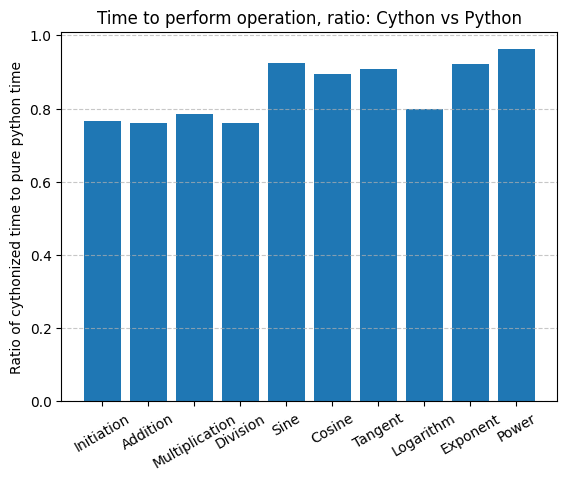

In [18]:
ratios = np.array(cython_times) / np.array(python_times)
plt.bar(indices, ratios)
plt.ylabel("Ratio of cythonized time to pure python time")
plt.xticks(indices, labels, rotation=30)
plt.grid(axis='y', linestyle = '--', alpha = 0.7)
plt.title("Time to perform operation, ratio: Cython vs Python")

print(ratios)
print(np.mean(ratios))

## Memory comparison

In [22]:
from memory_profiler import memory_usage

# Function to wrap and measure memory
def measure_memory(func):
    mem_usage = memory_usage((func))
    return max(mem_usage)  # Return the peak memory usage during the function execution

# Python version of the package: perform operations and track memory usage

# Store memory comparisons
python_memory = []

# Single instance creation
memory_taken = measure_memory(lambda: Dual(1, 5)) 
python_memory.append(memory_taken)

# Addition
memory_taken = measure_memory(lambda: Dual(2, 1) + Dual(3, 2))
python_memory.append(memory_taken)

# Multiplication
memory_taken = measure_memory(lambda: Dual(2, 1) * Dual(3, 2))
python_memory.append(memory_taken)

# Division
memory_taken = measure_memory(lambda: Dual(2, 1) / Dual(4, 2))
python_memory.append(memory_taken)

# Sine
memory_taken = measure_memory(lambda: Dual(2, 1).sin())
python_memory.append(memory_taken)

# Cosine
memory_taken = measure_memory(lambda: Dual(2, 1).cos())
python_memory.append(memory_taken)

# Tangent
memory_taken = measure_memory(lambda: Dual(2, 1).tan())
python_memory.append(memory_taken)

# Logarithm
memory_taken = measure_memory(lambda: Dual(2, 1).log())
python_memory.append(memory_taken)

# Exponentiation
memory_taken = measure_memory(lambda: Dual(2, 1).exp())
python_memory.append(memory_taken)

# Power
memory_taken = measure_memory(lambda: Dual(2, 1) ** Dual(3,2))
python_memory.append(memory_taken)



In [23]:
# Cython version of the package: perform operations and track memory
cython_memory = []

# Single instance creation
memory_taken = measure_memory(lambda: dfx.Dual(1, 5))
cython_memory.append(memory_taken)

# Addition
memory_taken = measure_memory(lambda: dfx.Dual(2, 1) + dfx.Dual(3, 2))
cython_memory.append(memory_taken)

# Multiplication
memory_taken = measure_memory(lambda: dfx.Dual(2, 1) * dfx.Dual(3, 2))
cython_memory.append(memory_taken)

# Division
memory_taken = measure_memory(lambda: dfx.Dual(2, 1) / dfx.Dual(4, 2))
cython_memory.append(memory_taken)

# Sine
memory_taken = measure_memory(lambda: dfx.Dual(2, 1).sin())
cython_memory.append(memory_taken)

# Cosine
memory_taken = measure_memory(lambda: dfx.Dual(2, 1).cos())
cython_memory.append(memory_taken)

# Tangent
memory_taken = measure_memory(lambda: dfx.Dual(2, 1).tan())
cython_memory.append(memory_taken)

# Logarithm
memory_taken = measure_memory(lambda: dfx.Dual(2, 1).log())
cython_memory.append(memory_taken)

# Exponentiation
memory_taken = measure_memory(lambda: dfx.Dual(2, 1).exp())
cython_memory.append(memory_taken)

# Power
memory_taken = measure_memory(lambda: dfx.Dual(2, 1) ** dfx.Dual(3,2))
cython_memory.append(memory_taken)

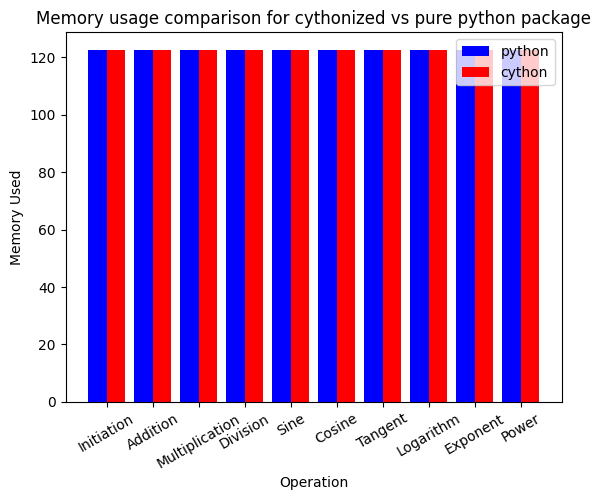

In [24]:
# making a bar plot to see the difference in memory usage between cython and python versions
methods = ['Python', 'Cython']

# Create the bar positions
indices = np.arange(len(python_memory))

# Custom text labels for x-axis
labels = ['Initiation', 'Addition', 'Multiplication', 'Division', 'Sine', 'Cosine',
        'Tangent', 'Logarithm', 'Exponent', 'Power']  # Text labels for x-axis

# Plot the bars
plt.bar(indices - 0.2, python_memory, width=0.4, label='python', color='b')
plt.bar(indices + 0.2, cython_memory, width=0.4, label='cython', color='r')

# Customize plot
plt.xlabel("Operation")
plt.ylabel("Memory Used")
plt.title("Memory usage comparison for cythonized vs pure python package")
plt.xticks(indices, labels, rotation=30)
plt.legend()

# Show plot
plt.show()